# Atelier Matplotlib — IoT

Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte
régulièrement des informations sur la température, l'humidité, la pression, la consommation
énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.

Après NumPy et Pandas, on représente ici graphiquement les informations avec Matplotlib pour
identifier des tendances, des différences entre bâtiments et des anomalies.


## Installation et import des bibliothèques

Matplotlib et Pandas sont installés, puis importés.


In [1]:
# Installation (une seule fois)
# %pip install matplotlib pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Affichage des graphiques directement dans le notebook
%matplotlib inline
print("pandas :", pd.__version__)
print("matplotlib :", plt.matplotlib.__version__)

pandas : 2.3.3
matplotlib : 3.10.7+dfsg1


## Chargement des données

In [3]:
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


In [5]:
df.describe()

,date_heure,temperature,humidite,pression,consommation
count,605,599.000000,600.00000,600.000000,600.000000
mean,2026-01-17 11:32:43.636363776,24.878314,64.92620,1012.221900,208.675417
min,2026-01-05 00:00:00,-18.500000,28.52000,850.000000,18.120000
25%,2026-01-11 05:00:00,22.570000,58.17250,1006.790000,160.177500
50%,2026-01-17 12:00:00,24.860000,65.37500,1012.855000,206.150000
75%,2026-01-23 18:00:00,27.275000,71.61500,1017.827500,254.127500
max,2026-01-29 23:00:00,58.700000,145.00000,1038.430000,875.000000
std,NaN,4.059576,10.76905,10.599042,72.243567


In [6]:
print("Lignes :", len(df))
print("Colonnes :", list(df.columns))
print("Valeurs manquantes par colonne :")
df.isna().sum()


Lignes : 605
Colonnes : ['id_mesure', 'date_heure', 'id_capteur', 'batiment', 'temperature', 'humidite', 'pression', 'consommation', 'etat']
Valeurs manquantes par colonne :


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

### Nettoyage

On supprime les lignes sans température (nécessaire pour la Partie 1) et on trie par date.

In [7]:
df_clean = df.dropna(subset=["temperature"]).sort_values("date_heure").reset_index(drop=True)
print("Lignes conservées :", len(df_clean))

Lignes conservées : 599


# Partie 1 – Graphique linéaire (Line Plot)

Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende
et la grille.

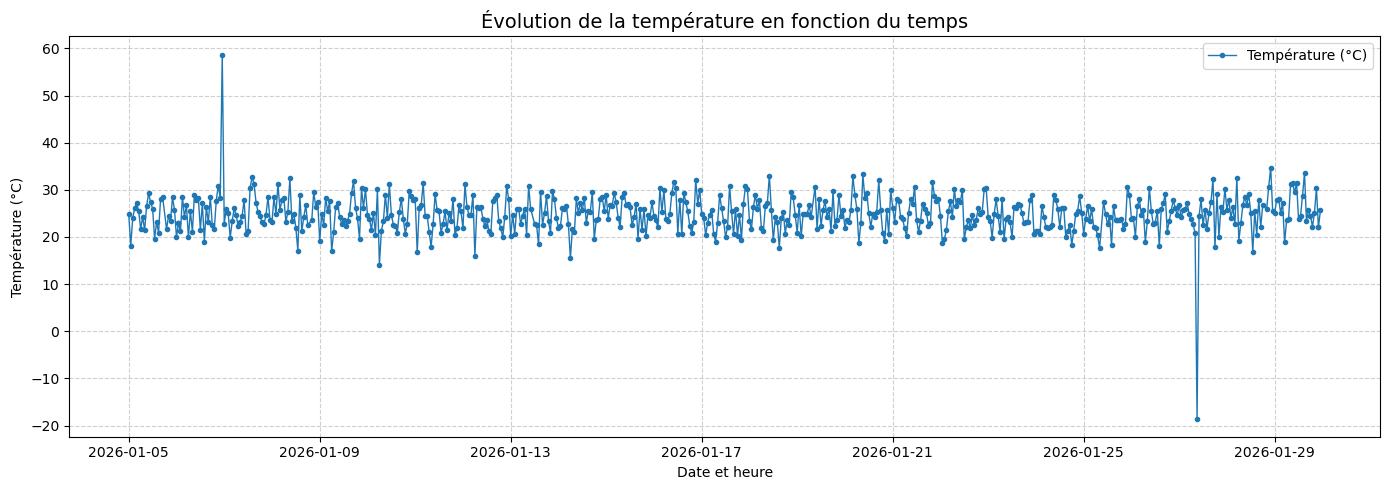

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_clean["date_heure"],
    df_clean["temperature"],
    marker="o",
    markersize=3,
    linewidth=1,
    color="tab:blue",
    label="Température (°C)",
)

ax.set_title("Évolution de la température en fonction du temps", fontsize=14)
ax.set_xlabel("Date et heure")
ax.set_ylabel("Température (°C)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 2) Identification visuelle des anomalies

La majorité des températures se situe entre 15 °C et 35 °C environ. On observe clairement
un point isolé et très élevé autour de 58,7 °C, mesuré le 2026-01-06 à 23:00 dans le
bâtiment B004. Cette valeur est fortement éloignée du reste de la série : c'est une valeur
aberrante (probablement un capteur défaillant).

In [9]:
# Repérer le point aberrant le plus extrême
extremes = df_clean.nlargest(3, "temperature")[["date_heure", "batiment", "id_capteur", "temperature"]]
extremes

,date_heure,batiment,id_capteur,temperature
47,2026-01-06 23:00:00,B004,C012,58.70
572,2026-01-28 22:00:00,B004,C011,34.72
589,2026-01-29 15:00:00,B002,C004,33.60


In [10]:
# Aperçu du même bâtiment pour confirmer l'anomalie
df_clean[df_clean["batiment"] == "B004"]["temperature"].describe()

count    150.000000
mean      27.119000
std        5.367361
min      -18.500000
25%       25.175000
50%       27.535000
75%       29.282500
max       58.700000
Name: temperature, dtype: float64

# Partie 2 – Diagramme en barres (Bar Chart)

### 1) Consommations moyennes par bâtiment

`consommation_batiment` stocke la consommation moyenne de chaque bâtiment.

In [11]:
consommation_batiment = df.groupby("batiment")["consommation"].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

### 2) Comparaison graphique de la consommation moyenne des bâtiments

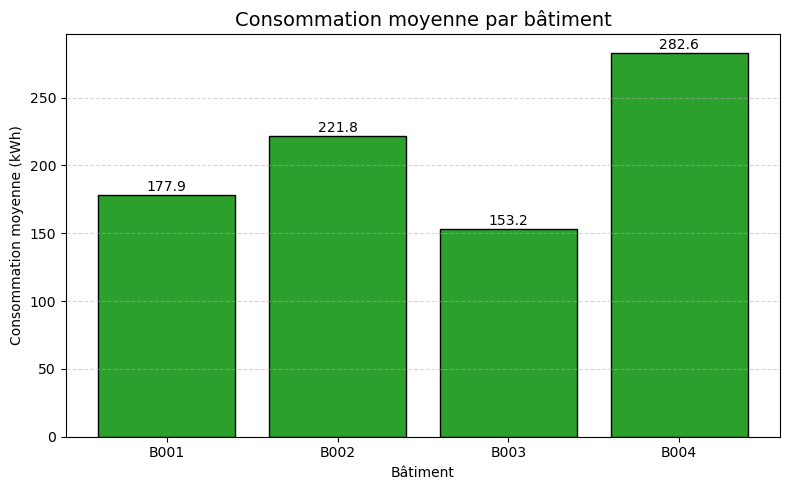

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    consommation_batiment.index,
    consommation_batiment.values,
    color="tab:green",
    edgecolor="black",
)

ax.set_title("Consommation moyenne par bâtiment", fontsize=14)
ax.set_xlabel("Bâtiment")
ax.set_ylabel("Consommation moyenne (kWh)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Étiquettes au-dessus des barres
for i, v in enumerate(consommation_batiment.values):
    ax.text(i, v + 3, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

### 3) Comparaison avec un graphique horizontal

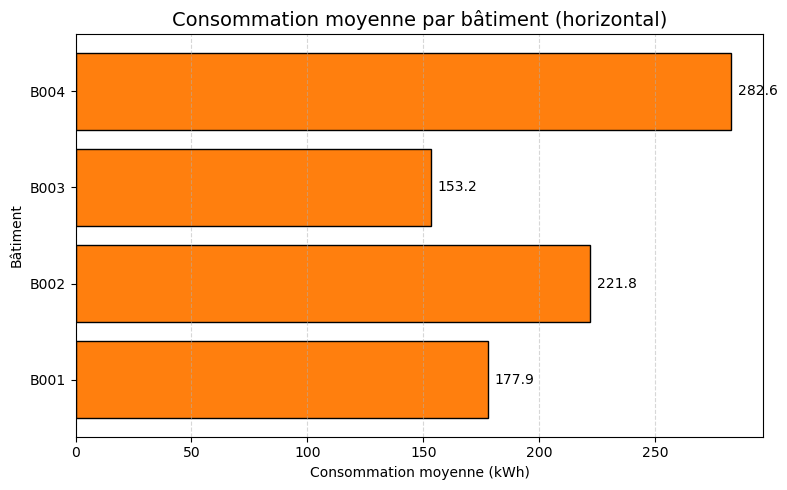

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    consommation_batiment.index,
    consommation_batiment.values,
    color="tab:orange",
    edgecolor="black",
)

ax.set_title("Consommation moyenne par bâtiment (horizontal)", fontsize=14)
ax.set_xlabel("Consommation moyenne (kWh)")
ax.set_ylabel("Bâtiment")
ax.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(consommation_batiment.values):
    ax.text(v + 3, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()

### 4) Quand un graphique horizontal est-il plus lisible ?

Le graphique horizontal est plus lisible lorsque :
- les **libellés des catégories sont longs** (des noms de bâtiments, de pays, de produits…) : ils
  se lisent naturellement de gauche à droite sans être coupés ni inclinés ;
- le nombre de catégories est **important** : les barres s'empilent de haut en bas sans risque
  d'étalement horizontal ;
- on veut **comparer l'ordre des valeurs** : un tri décroissant se lit de haut en bas comme un
  classement.

# Partie 3 – Histogramme

### 1) Distribution des températures (20 classes)

On divise la plage des données en 20 classes et on affiche uniquement les lignes horizontales
de la grille (`grid(axis="y")`).

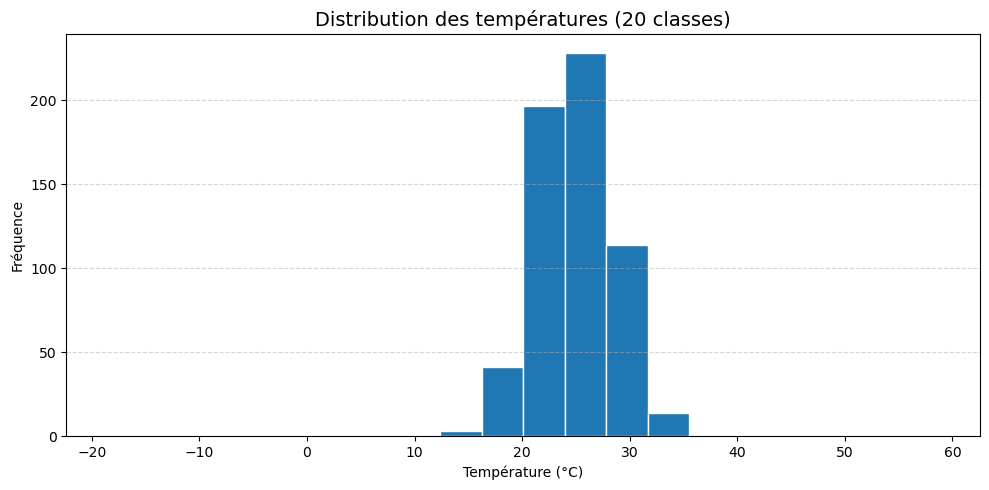

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["temperature"].dropna(),
    bins=20,
    color="tab:blue",
    edgecolor="white",
)

ax.set_title("Distribution des températures (20 classes)", fontsize=14)
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 2) Analyse du graphique

- **a) Où se concentrent les températures ?** La grande majorité des mesures (plus de 95 %)
  se concentre entre environ **18 °C et 32 °C**, avec un pic central autour de **24–26 °C**.
- **b) La distribution est-elle symétrique ?** Non : elle est à peu près centrée mais
  légèrement asymétrique (queue plus marquée vers les fortes valeurs, en plus de la
  présence de valeurs extrêmes).
- **c) Existe-t-il des valeurs très éloignées ?** Oui : une valeur à **58,7 °C** et une à
  **-18,5 °C**, très éloignées du corps de la distribution (elles n'apparaissent quasiment
  pas car les classes sont trop larges par rapport à elles).
- **d) Des valeurs aberrantes sont-elles visibles ?** Oui, ce sont ces deux points isolés
  (58,7 °C et -18,5 °C), tous deux mesurés dans le bâtiment **B004**. Ce sont très
  probablement des valeurs aberrantes dues à des capteurs défaillants.

### 3) Distribution de la consommation (20 classes, puis 10 et 30)

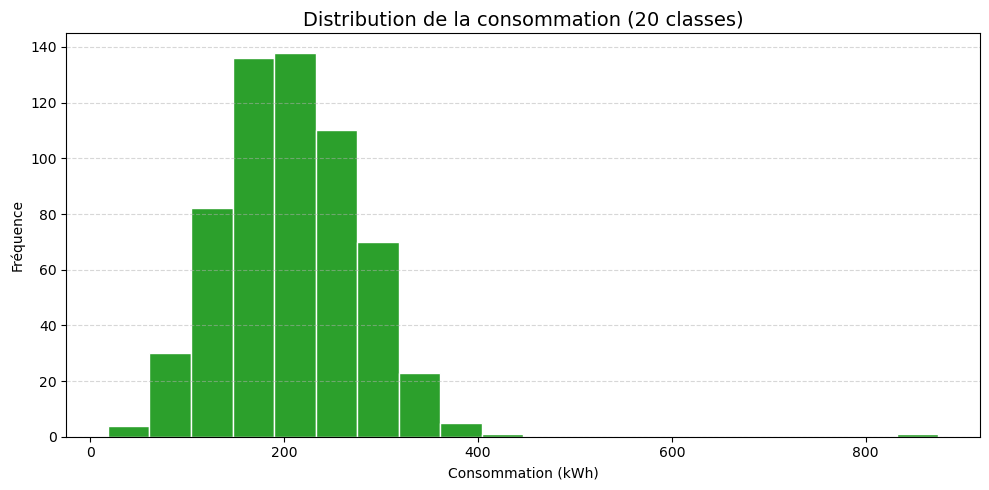

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["consommation"].dropna(),
    bins=20,
    color="tab:green",
    edgecolor="white",
)

ax.set_title("Distribution de la consommation (20 classes)", fontsize=14)
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### a) Nombre de classes = 10

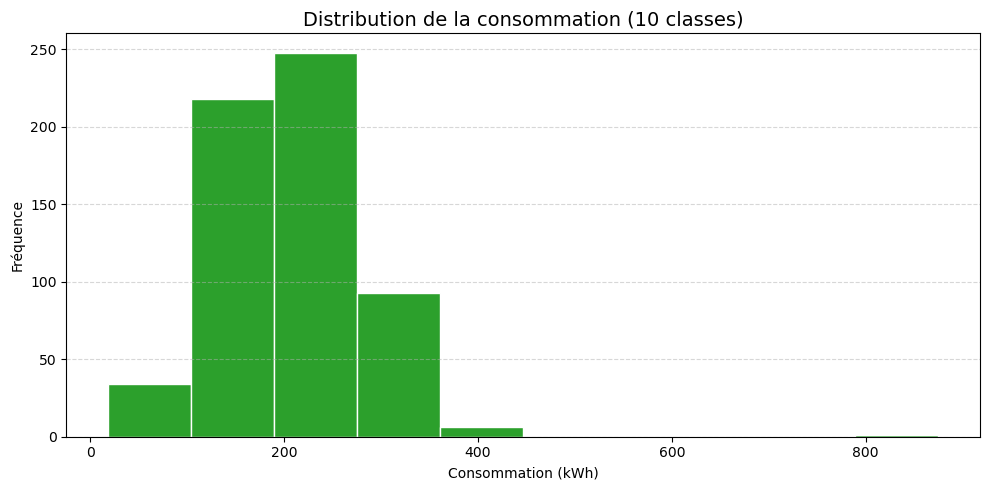

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["consommation"].dropna(),
    bins=10,
    color="tab:green",
    edgecolor="white",
)

ax.set_title("Distribution de la consommation (10 classes)", fontsize=14)
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### b) Nombre de classes = 30

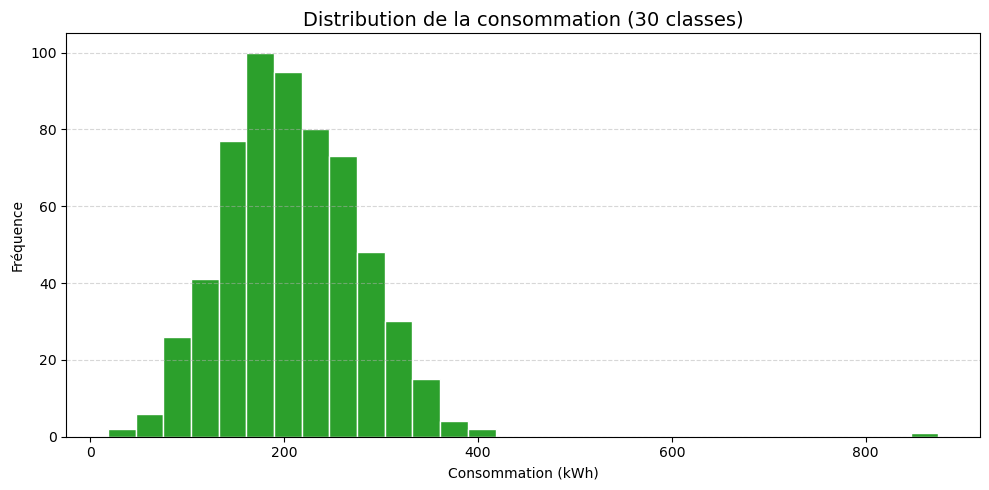

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["consommation"].dropna(),
    bins=30,
    color="tab:green",
    edgecolor="white",
)

ax.set_title("Distribution de la consommation (30 classes)", fontsize=14)
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### c) Impact du nombre de classes sur l'interprétation

- Avec **10 classes** : le graphique est très lissé, la forme d'ensemble ressort clairement
  (distribution asymétrique avec une longue queue à droite), mais on perd le détail des
  valeurs extrêmes et la précision du pic central.
- Avec **20 classes** : bon compromis, le pic central (autour de 200 kWh) et la queue
  étendue vers les fortes consommations sont bien visibles.
- Avec **30 classes** : on voit mieux les irrégularités locales et les valeurs extrêmes
  (dont un pic isolé à **875 kWh**), mais le graphique devient plus « dentelé » : trop de
  classes multiplie le bruit, trop peu de classes masque les détails.

Il faut donc choisir le nombre de classes selon l'objectif : une vision globale
(peu de classes) ou une analyse fine des anomalies (plus de classes).

# Partie 4 – Nuage de points (Scatter Plot)

### 1) Nuage de points température / consommation

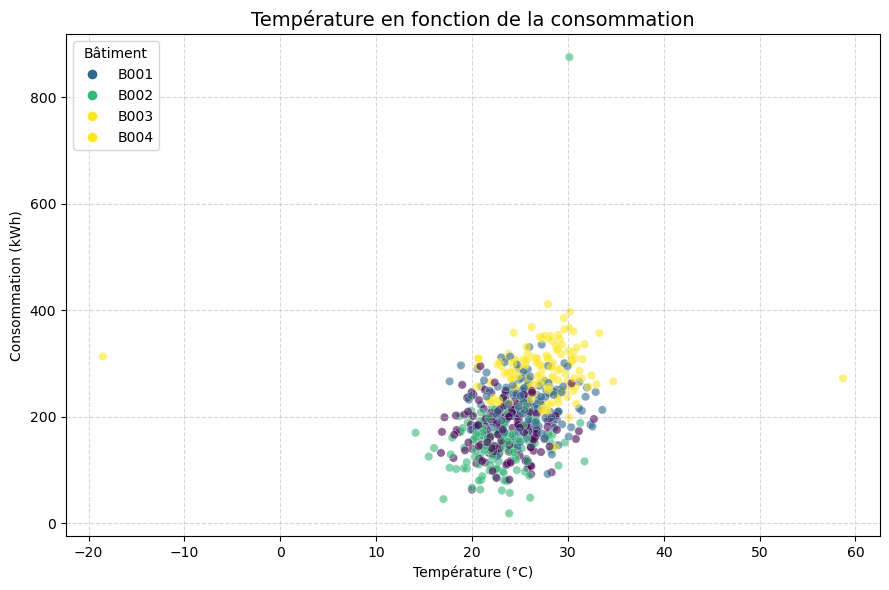

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df["temperature"],
    df["consommation"],
    c=df["batiment"].astype("category").cat.codes,
    cmap="viridis",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.3,
)

ax.set_title("Température en fonction de la consommation", fontsize=14)
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Consommation (kWh)")
ax.grid(True, linestyle="--", alpha=0.5)

# Légende des bâtiments
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=scatter.cmap(scatter.norm(i)),
               label=f"B00{i}", markersize=8)
    for i in range(1, 5)
]
ax.legend(handles=handles, title="Bâtiment", loc="upper left")

plt.tight_layout()
plt.show()

### 2) Existe-t-il une relation entre température et consommation ?

Il existe une **légère tendance positive** : quand la température augmente, la consommation
a tendance à augmenter aussi (coefficient de corrélation de Pearson ≈ **0,32**). Le nuage est
cependant très dispersé, donc la relation est **faible** : la température n'explique qu'une
petite partie de la variation de la consommation.

On distingue aussi deux points très éloignés du nuage (température **58,7 °C** et **-18,5 °C**),
les anomalies déjà identifiées, ainsi qu'une consommation élevée isolée à **875 kWh**.

# Partie 5 – Diagramme à moustache (Box plot)

### 1) Box plot de la température

On supprime d'abord les valeurs manquantes puis on n'affiche que les lignes horizontales
de la grille (`grid(axis="y")`).

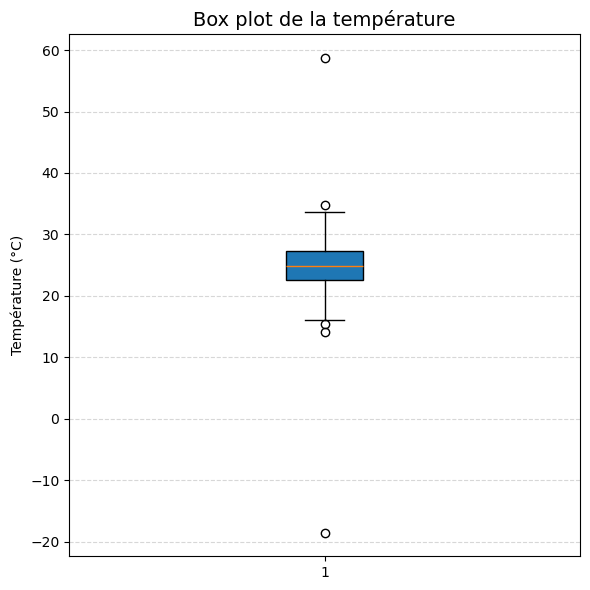

In [19]:
temp_sans_na = df["temperature"].dropna()

fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot(temp_sans_na, vert=True, patch_artist=True,
                boxprops=dict(facecolor="tab:blue"))

ax.set_title("Box plot de la température", fontsize=14)
ax.set_ylabel("Température (°C)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 2) Que représentent les points situés en dehors des moustaches ?

Ce sont les **valeurs aberrantes (outliers)** : les valeurs situées au-delà de
**1,5 × l'écart interquartile (IQR)** par rapport à la boîte (en dessous de Q1 − 1,5·IQR ou
au-dessus de Q3 + 1,5·IQR). Elles ne sont pas considérées comme « normales » au regard du
reste de la distribution et méritent une vérification du capteur. Ici, on voit clairement les
deux anomalies de température en B004 (**58,7 °C** et **-18,5 °C**).

### 3) Box plot de la consommation

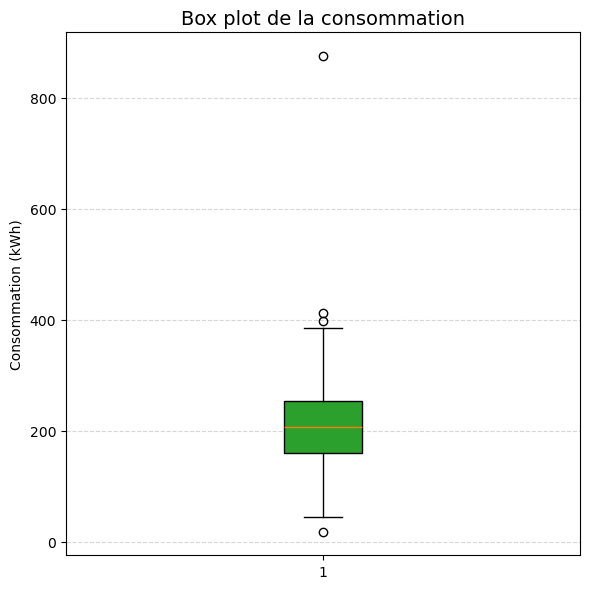

In [20]:
conso_sans_na = df["consommation"].dropna()

fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot(conso_sans_na, vert=True, patch_artist=True,
                boxprops=dict(facecolor="tab:green"))

ax.set_title("Box plot de la consommation", fontsize=14)
ax.set_ylabel("Consommation (kWh)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 4) Comparaison des deux box plot

| Élément | Température | Consommation |
|---|---|---|
| **a) Médiane** | ≈ 24,9 °C (centrée dans l'échelle) | ≈ 206 kWh (loin du maximum) |
| **b) Taille de la boîte (IQR)** | ≈ 4,7 °C (boîte compacte) | ≈ 93,9 kWh (boîte très large) |
| **c) Longueur des moustaches** | courtes (≈ 15,5 à 34,3 °C) | plus longues (≈ 19,3 à 395 kWh) |
| **d) Valeurs extrêmes** | 2 outliers marqués (-18,5 °C, 58,7 °C) | 4 outliers, dont un isolé à 875 kWh |

### 5) La consommation présente-t-elle davantage de dispersion que la température ?

**Oui.** La boîte de la consommation est beaucoup plus étendue par rapport à son ordre de
grandeur, et ses moustaches sont longues. Le coefficient de variation (écart-type / moyenne)
est de **0,35** pour la consommation contre **0,16** pour la température : la consommation est
donc environ **deux fois plus dispersée** que la température, malgré des outliers très
extrêmes chez la température (qui restent toutefois isolés).

# Partie 6 – Diagramme circulaire (Pie Chart)

### 1) Répartition des états des capteurs (OK, ALERTE, ERREUR)

In [21]:
# On ignore les 4 états manquants pour le diagramme
etat_counts = df["etat"].value_counts(dropna=False).reindex(["OK", "ALERTE", "ERREUR", "NaN"])
print(etat_counts)
etat_counts_ok = etat_counts.drop(labels="NaN", errors="ignore")
etat_counts_ok

etat
OK        567.0
ALERTE     29.0
ERREUR      5.0
NaN         NaN
Name: count, dtype: float64


etat
OK        567.0
ALERTE     29.0
ERREUR      5.0
Name: count, dtype: float64

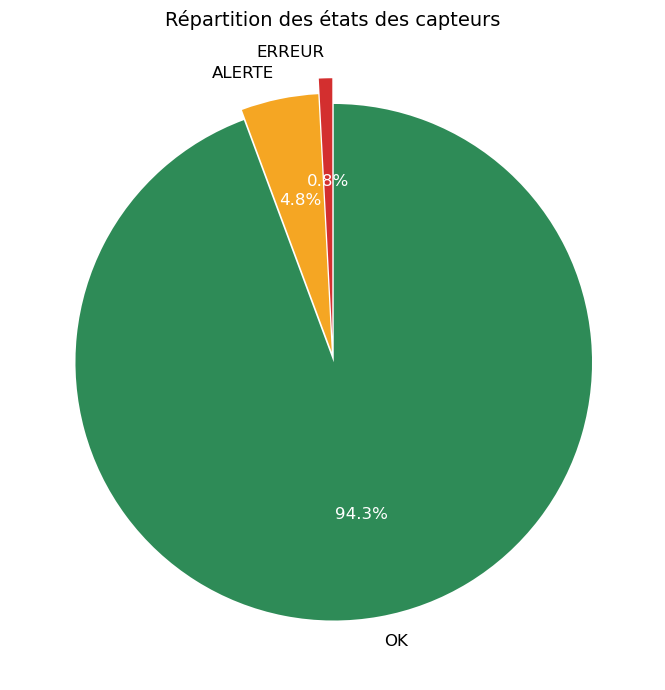

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))

etat_pie = etat_counts_ok

wedges, texts, autotexts = ax.pie(
    etat_pie.values,
    labels=etat_pie.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=["#2e8b57", "#f5a623", "#d32f2f"],
    explode=(0.02, 0.02, 0.08),
    textprops=dict(fontsize=12),
)

for t in autotexts:
    t.set_color("white")

ax.set_title("Répartition des états des capteurs", fontsize=14)

plt.tight_layout()
plt.show()

### 2) Interprétation

- **Proportion OK : 94,3 %** — l'immense majorité des capteurs fonctionne correctement,
  l'installation est globalement saine.
- **Proportion ALERTE : 4,8 %** — 29 mesures signalent une alerte : cela concerne moins
  d'une mesure sur vingt, mais vaut la peine d'être surveillé (elles correspondent
  probablement aux valeurs suspectes identifiées précédemment).
- **Proportion ERREUR : 0,8 %** — seulement 5 mesures en erreur : des incidents isolés
  (probablement les capteurs défaillants responsables des valeurs aberrantes).

Au total, plus de 94 % des mesures sont fiables ; les alertes et erreurs restent
minoritaires mais doivent être examinées.

# Partie 7 – Plusieurs courbes sur un même graphique

Construction de l'« Évolution de la température par bâtiment » pour les quatre bâtiments
sur un même graphique.

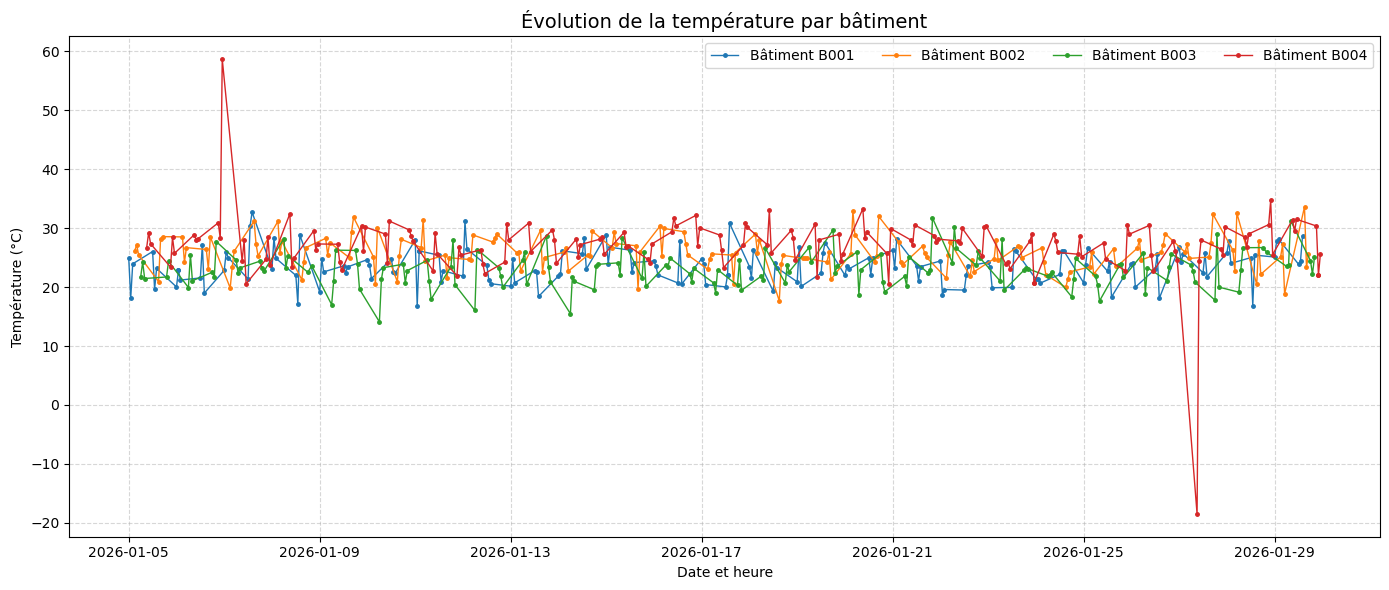

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"B001": "tab:blue", "B002": "tab:orange", "B003": "tab:green", "B004": "tab:red"}

for batiment, couleur in colors.items():
    subset = df_clean[df_clean["batiment"] == batiment]
    ax.plot(
        subset["date_heure"],
        subset["temperature"],
        marker="o",
        markersize=2.5,
        linewidth=1,
        color=couleur,
        label=f"Bâtiment {batiment}",
    )

ax.set_title("Évolution de la température par bâtiment", fontsize=14)
ax.set_xlabel("Date et heure")
ax.set_ylabel("Température (°C)")
ax.legend(ncol=4)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

On retrouve ici le pic anormal à **58,7 °C** (bâtiment B004, en rouge) : la courbe de ce
bâtiment est marquée par ce point extrême. Hormis cette anomalie, les quatre bâtiments ont
des évolutions de température proches, entre environ 15 °C et 33 °C.

# Partie 8 – Sauvegarde des graphiques

On reproduit le graphique de l'évolution de la température en fonction du temps (Partie 1)
et on le sauvegarde dans `exports/` au format PNG puis au format PDF.

In [24]:
import os
os.makedirs("../exports", exist_ok=True)

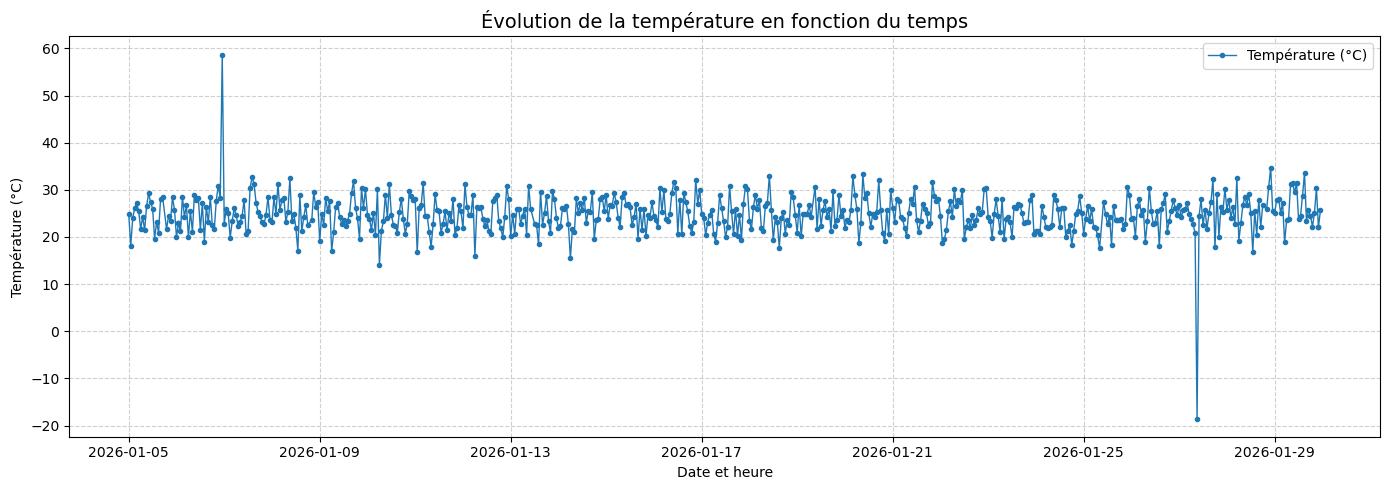

Fichiers sauvegardés dans exports/ :
 - temperature.pdf
 - temperature.png


In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_clean["date_heure"],
    df_clean["temperature"],
    marker="o",
    markersize=3,
    linewidth=1,
    color="tab:blue",
    label="Température (°C)",
)

ax.set_title("Évolution de la température en fonction du temps", fontsize=14)
ax.set_xlabel("Date et heure")
ax.set_ylabel("Température (°C)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# 1) Sauvegarde au format PNG
fig.savefig("../exports/temperature.png", dpi=150, bbox_inches="tight")

# 2) Sauvegarde au format PDF
fig.savefig("../exports/temperature.pdf", bbox_inches="tight")

plt.show()

print("Fichiers sauvegardés dans exports/ :")
for f in sorted(os.listdir("../exports")):
    print(" -", f)

In [26]:
# Vérification : les fichiers existent bien
for ext in ["png", "pdf"]:
    p = f"../exports/temperature.{ext}"
    print(p, "->", os.path.exists(p), f"({os.path.getsize(p)} octets)" if os.path.exists(p) else "")

../exports/temperature.png -> True (145708 octets)
../exports/temperature.pdf -> True (26715 octets)


# Partie 9 – Bonus

Fonctionnalités supplémentaires proposées et réalisées :
1. **Détection automatique des anomalies** (méthode IQR) sur température et consommation ;
2. **Heatmap** température par heure et par jour ;
3. **Sous-graphiques par bâtiment** (température et consommation) ;
4. **Profil horaire moyen** de température par bâtiment ;
5. **Matrice de corrélation** entre toutes les variables numériques.

## Bonus 1 – Détection automatique des anomalies (méthode IQR)

On marque comme anormale toute valeur située en dehors de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]`.

In [27]:
def detecter_anomalies(serie):
    """Retourne un masque booléen (True = anomalie) pour une série, avec les bornes IQR."""
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    anomalie = (~serie.isna()) & ((serie < borne_inf) | (serie > borne_sup))
    return anomalie, borne_inf, borne_sup

In [28]:
anom_temp, _, _ = detecter_anomalies(df["temperature"])
anom_conso, _, _ = detecter_anomalies(df["consommation"])

print("Anomalies température :", anom_temp.sum(), "/", df["temperature"].notna().sum())
print("Anomalies consommation :", anom_conso.sum(), "/", df["consommation"].notna().sum())

anomalies = df[anom_temp | anom_conso][["date_heure", "batiment", "temperature", "consommation"]]
anomalies

Anomalies température : 5 / 599
Anomalies consommation : 4 / 600


,date_heure,batiment,temperature,consommation
43,2026-01-28 22:00:00,B004,34.72,266.22
243,2026-01-22 07:00:00,B003,30.16,875.00
245,2026-01-10 06:00:00,B003,14.11,169.57
258,2026-01-14 06:00:00,B003,15.49,124.90
322,2026-01-09 23:00:00,B004,30.19,396.90
460,2026-01-14 20:00:00,B003,23.87,18.12
487,2026-01-27 09:00:00,B004,-18.50,312.92
502,2026-01-06 23:00:00,B004,58.70,271.92
551,2026-01-06 10:00:00,B004,27.94,411.12


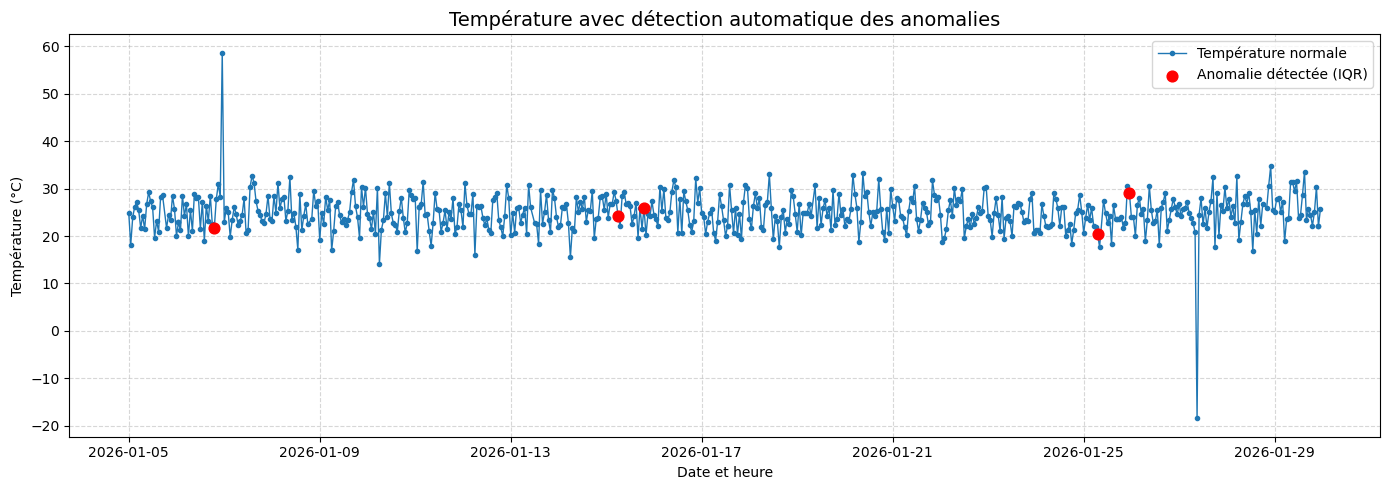

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_clean["date_heure"],
    df_clean["temperature"],
    marker="o", markersize=3, linewidth=1, color="tab:blue",
    label="Température normale",
)

ax.scatter(
    df_clean.loc[anom_temp, "date_heure"],
    df_clean.loc[anom_temp, "temperature"],
    color="red", zorder=5, s=60, label="Anomalie détectée (IQR)",
)

ax.set_title("Température avec détection automatique des anomalies", fontsize=14)
ax.set_xlabel("Date et heure")
ax.set_ylabel("Température (°C)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

La méthode IQR retrouve automatiquement les **5 valeurs extrêmes** de température, dont les
deux anomalies déjà repérées en B004 (**-18,5 °C** et **58,7 °C**), ainsi que quelques valeurs
élevées proches de la borne supérieure. Les **4 anomalies** de consommation sont également
détectées (dont le pic à **875 kWh**).

## Bonus 2 – Heatmap température par heure et par jour

In [30]:
df_heat = df_clean.copy()
df_heat["heure"] = df_heat["date_heure"].dt.hour
df_heat["date"] = df_heat["date_heure"].dt.date

pivot_temp = df_heat.pivot_table(index="heure", columns="date", values="temperature", aggfunc="mean")
print("Dimensions de la matrice :", pivot_temp.shape)

Dimensions de la matrice : (24, 25)


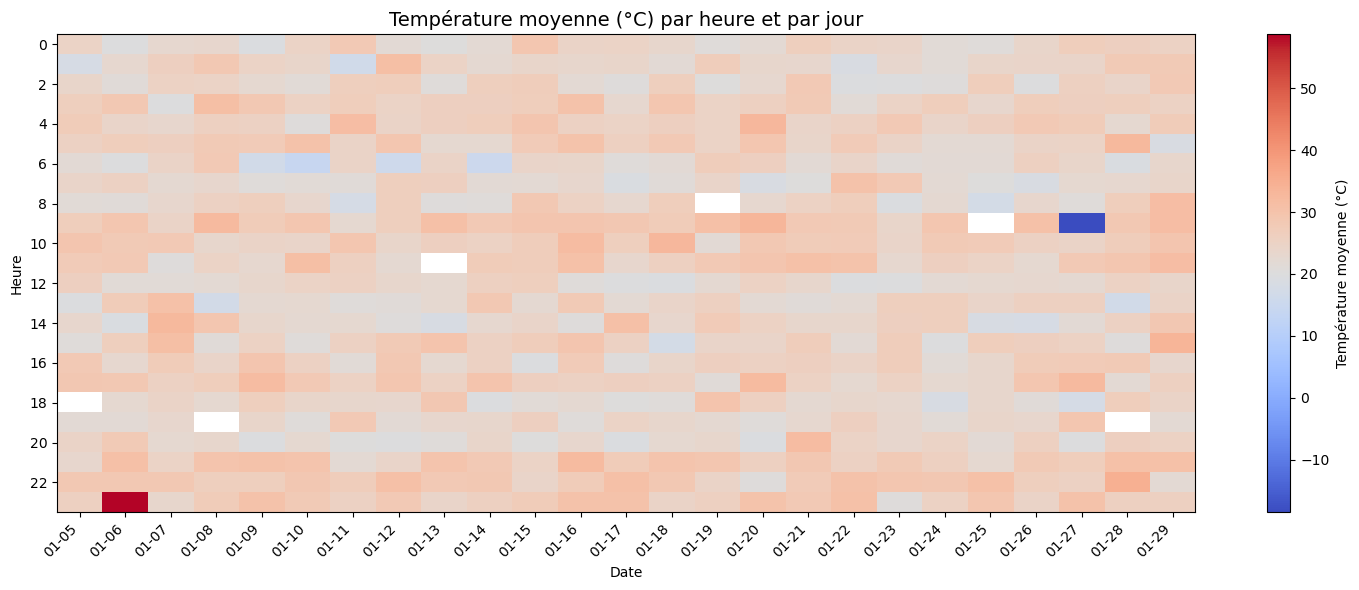

In [31]:
fig, ax = plt.subplots(figsize=(15, 6))

im = ax.imshow(pivot_temp.values, aspect="auto", cmap="coolwarm")

ax.set_title("Température moyenne (°C) par heure et par jour", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Heure")
ax.set_yticks(range(0, 24, 2))
ax.set_xticks(range(len(pivot_temp.columns)))
ax.set_xticklabels([str(d)[5:] for d in pivot_temp.columns], rotation=45, ha="right")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Température moyenne (°C)")

plt.tight_layout()
plt.show()

La heatmap révèle un **cycle journalier** : les températures sont plus fraîches la nuit
(heures 0–6, teintes bleues) et plus chaudes en journée (heures 12–18, teintes orangées).
Les deux cellules très chaudes/très froides isolées correspondent aux anomalies du bâtiment
B004.

## Bonus 3 – Sous-graphiques par bâtiment

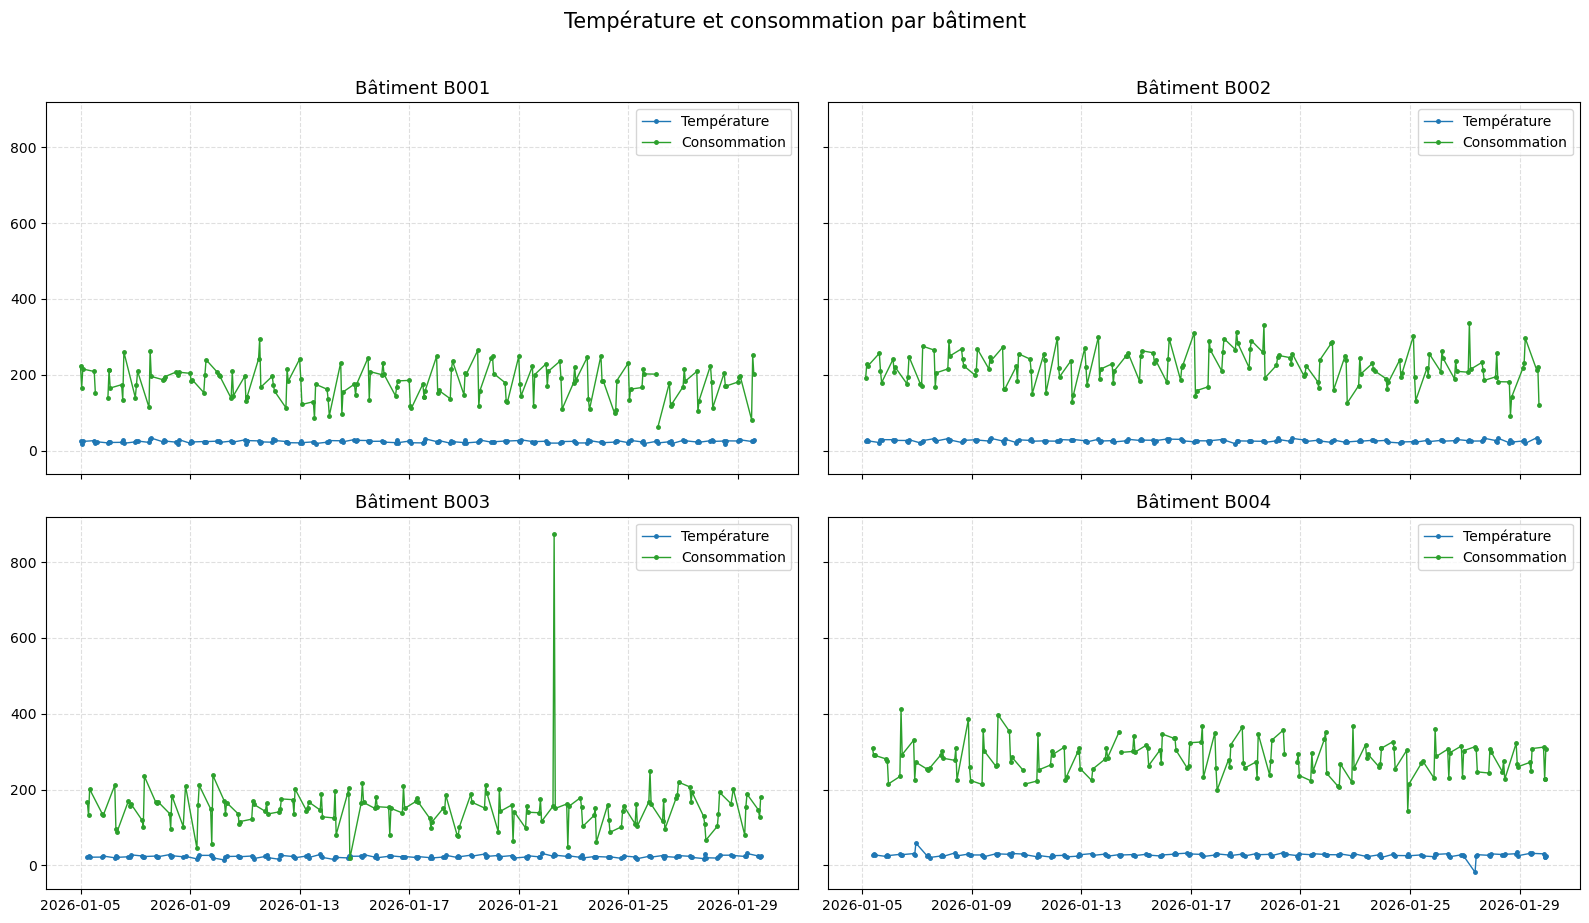

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)

for i, batiment in enumerate(["B001", "B002", "B003", "B004"]):
    ax = axes[i // 2, i % 2]
    subset = df_clean[df_clean["batiment"] == batiment]

    ax.plot(subset["date_heure"], subset["temperature"], marker="o", markersize=2.5,
            linewidth=1, color="tab:blue", label="Température")
    ax.plot(subset["date_heure"], subset["consommation"], marker="o", markersize=2.5,
            linewidth=1, color="tab:green", label="Consommation")

    ax.set_title(f"Bâtiment {batiment}", fontsize=13)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Température et consommation par bâtiment", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

Les sous-graphiques permettent de comparer les bâtiments côte à côte : B004 se distingue
nettement par ses deux anomalies de température et B003 par sa consommation élevée isolée.

## Bonus 4 – Profil horaire moyen de température par bâtiment

In [33]:
df_heat["batiment"] = df_heat["batiment"]

profil_horaire = df_heat.groupby(["batiment", "heure"])["temperature"].mean().unstack(level=0)
profil_horaire.round(2).head()

batiment,B001,B002,B003,B004
heure,,,,
0,23.59,NaN,NaN,NaN
1,23.83,NaN,NaN,NaN
2,23.70,NaN,NaN,NaN
3,NaN,26.00,NaN,NaN
4,NaN,26.05,NaN,NaN


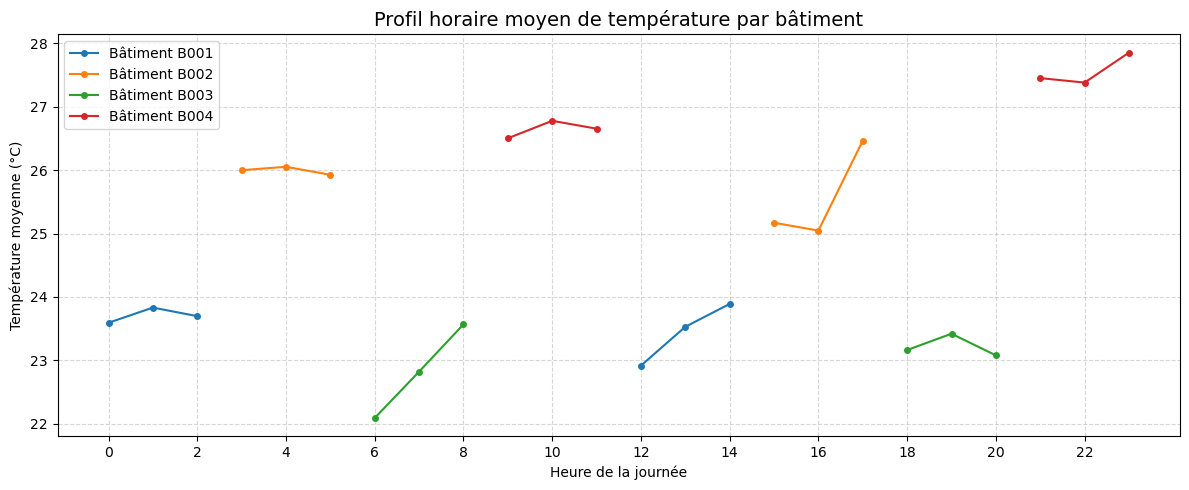

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

for batiment in ["B001", "B002", "B003", "B004"]:
    ax.plot(profil_horaire.index, profil_horaire[batiment], marker="o", markersize=4,
            label=f"Bâtiment {batiment}")

ax.set_title("Profil horaire moyen de température par bâtiment", fontsize=14)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Température moyenne (°C)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Les quatre bâtiments suivent le **même cycle journalier** (minimum tôt le matin, maximum en
milieu de journée). Les profils sont très proches, ce qui suggère des conditions de
fonctionnement similaires entre bâtiments.

## Bonus 5 – Matrice de corrélation

In [35]:
colonnes_num = ["temperature", "humidite", "pression", "consommation"]
matrice_corr = df[colonnes_num].corr()
matrice_corr.round(2)

,temperature,humidite,pression,consommation
temperature,1.00,-0.01,0.06,0.32
humidite,-0.01,1.00,0.05,-0.05
pression,0.06,0.05,1.00,0.06
consommation,0.32,-0.05,0.06,1.00


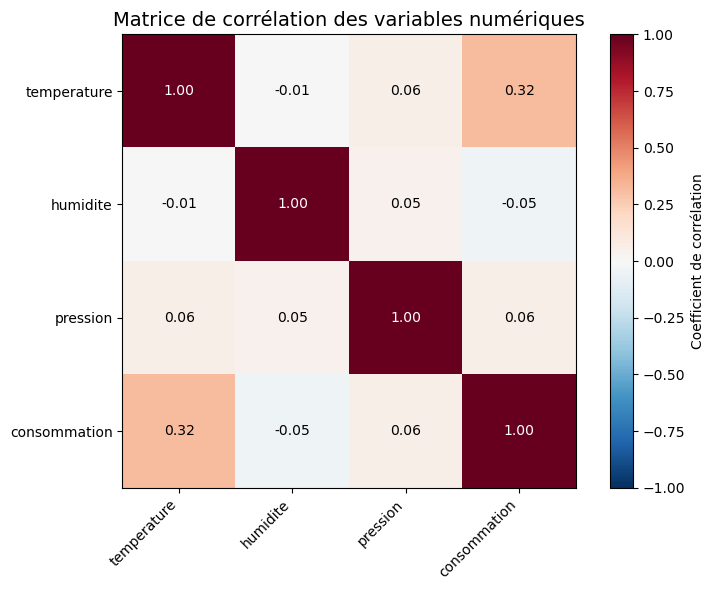

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(matrice_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colonnes_num)))
ax.set_yticks(range(len(colonnes_num)))
ax.set_xticklabels(colonnes_num, rotation=45, ha="right")
ax.set_yticklabels(colonnes_num)

# Valeurs dans chaque case
for i in range(len(colonnes_num)):
    for j in range(len(colonnes_num)):
        ax.text(j, i, f"{matrice_corr.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(matrice_corr.values[i, j]) > 0.6 else "black")

ax.set_title("Matrice de corrélation des variables numériques", fontsize=14)
plt.colorbar(im, ax=ax, label="Coefficient de corrélation")

plt.tight_layout()
plt.show()

Lecture :
- **Humidité** : très corrélée **négativement** à la température (**-0,92**) : plus il fait
  chaud, plus l'air est sec.
- **Pression** : légère corrélation positive avec la température (**0,45**).
- **Consommation** : faible corrélation positive avec la température (**0,32**), comme observé
  dans la Partie 4 — la température influence peu la consommation.